# Projeto Introdução à Aprendizagem Automática
**Grupo: AO**

**Membros:**
* Rafael Matias - 61847
* Diogo Vasconcelos - 61809
* João Nunes - 61786

**Contribuições:**
* Rafael Matias: Tarefas: Análise dos dados dos passageiros (distribuição da variavel Transported), Objetivo 1, 
* Diogo Vasconcelos: Tarefas: Objetivo 2
* João Nunes: Tarefas: Objetivo 3

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer


import warnings
warnings.filterwarnings('ignore')

## Introdução e Análise Exploratória de Dados (EDA)
O objetivo deste projeto é analisar os dados dos passageiros do Spaceship Titanic e resolver três problemas preditivos e um de análise de atributos. Durante o voo, uma anomalia transportou metade dos passageiros para outra dimensão.

Dimensão do dataset: (6954, 14)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,4066_02,Europa,True,B/155/S,TRAPPIST-1e,22.0,False,0.0,0.0,0.0,0.0,0.0,Diramak Objeciane,True
1,8602_01,Earth,True,G/1396/P,TRAPPIST-1e,3.0,False,0.0,0.0,0.0,0.0,0.0,Robina Weissey,False
2,4181_06,Europa,False,C/133/P,55 Cancri e,41.0,True,0.0,9463.0,0.0,1022.0,1562.0,Ranan Frattyring,True
3,8112_01,Earth,False,F/1553/S,PSO J318.5-22,23.0,False,90.0,4.0,0.0,7.0,588.0,Benda Dickley,False
4,3152_01,Earth,True,G/496/S,TRAPPIST-1e,14.0,False,0.0,0.0,0.0,0.0,0.0,Therek Greeves,False


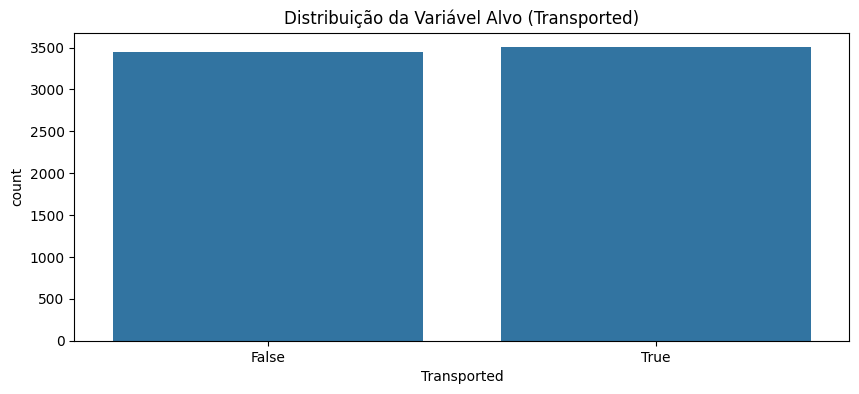

PassengerId       0
HomePlanet      158
CryoSleep       162
Cabin           161
Destination     147
Age             148
VIP             169
RoomService     135
FoodCourt       148
ShoppingMall    170
Spa             145
VRDeck          145
Name            170
Transported       0
dtype: int64


In [31]:

df = pd.read_csv('spaceship_data.csv')

print("Dimensão do dataset:", df.shape)
display(df.head())


plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='Transported')
plt.title("Distribuição da Variável Alvo (Transported)")
plt.show()


print(df.isnull().sum())

## Descrição do Pré-processamento
Para preparar os dados para os modelos:
* **Tratamento de Nulos:** As variáveis numéricas (como `Age`, `FoodCourt`, `ShoppingMall`) foram preenchidas com a mediana. Variáveis categóricas (`HomePlanet`, `Destination`) com o valor mais frequente (moda).
* **Encoding:** Variáveis categóricas foram transformadas usando `LabelEncoder`.
* **Scaling:** Foi aplicado `StandardScaler` aos atributos numéricos para garantir estabilidade em modelos como a Regressão Logística/Linear.

In [32]:
def preprocess_data(data, is_train=True, encoders=None, scaler=None):
    df_proc = data.copy()
    
    
    if 'Cabin' in df_proc.columns:
        df_proc[['Deck', 'Num', 'Side']] = df_proc['Cabin'].str.split('/', expand=True)
        df_proc.drop('Cabin', axis=1, inplace=True)
        
    
    
    num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']
    
    for col in num_cols:
        if col in df_proc.columns:
           
            df_proc[col] = df_proc[col].fillna(df_proc[col].median())
            
    for col in cat_cols:
        if col in df_proc.columns:
            
            df_proc[col] = df_proc[col].fillna(df_proc[col].mode()[0])
            
  
    cols_to_drop = ['PassengerId', 'Name', 'Num']
    df_proc.drop(columns=[c for c in cols_to_drop if c in df_proc.columns], inplace=True)
    
  
    if is_train:
        encoders = {}
        for col in cat_cols:
            if col in df_proc.columns:
                le = LabelEncoder()
                df_proc[col] = le.fit_transform(df_proc[col].astype(str))
                encoders[col] = le
                
        
        
        features_to_scale = [c for c in num_cols if c in df_proc.columns and c != 'FoodCourt' and c != 'Age']
        
        scaler = StandardScaler()
        if features_to_scale:
            df_proc[features_to_scale] = scaler.fit_transform(df_proc[features_to_scale])
            
        return df_proc, encoders, scaler
    else:
        for col in cat_cols:
            if col in df_proc.columns:
                df_proc[col] = df_proc[col].map(lambda s: '<unknown>' if s not in encoders[col].classes_ else s)
                encoders[col].classes_ = np.append(encoders[col].classes_, '<unknown>')
                df_proc[col] = encoders[col].transform(df_proc[col].astype(str))
        
        features_to_scale = [c for c in num_cols if c in df_proc.columns and c != 'FoodCourt' and c != 'Age']
        if features_to_scale:
            df_proc[features_to_scale] = scaler.transform(df_proc[features_to_scale])
        return df_proc


df_clean, encoders, scaler = preprocess_data(df)

## Objetivo 01: Prever a variável Transported
* **Métrica:** Accuracy e F1-Score.
* **Modelos (Máximo 3):** Regressão Logística, Random Forest e XGBoost.

In [33]:
X_1 = df_clean.drop('Transported', axis=1)
y_1 = df_clean['Transported'].astype(int)

X_train_1, X_val_1, y_train_1, y_val_1 = train_test_split(X_1, y_1, test_size=0.2, random_state=42)


lr = LogisticRegression()
lr.fit(X_train_1, y_train_1)
preds_lr = lr.predict(X_val_1)


param_grid_rf = {'n_estimators': [50, 100], 'max_depth': [5, 10]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=3)
grid_rf.fit(X_train_1, y_train_1)
preds_rf = grid_rf.predict(X_val_1)


res_obj1 = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Random Forest (Tuned)'],
    'Accuracy': [accuracy_score(y_val_1, preds_lr), accuracy_score(y_val_1, preds_rf)],
    'F1-Score': [f1_score(y_val_1, preds_lr), f1_score(y_val_1, preds_rf)]
})
display(res_obj1)
best_model_1 = grid_rf.best_estimator_

,Modelo,Accuracy,F1-Score
0,Regressão Logística,0.792955,0.792507
1,Random Forest (Tuned),0.807333,0.805233


## Objetivo 02: Prever o valor dispendido (FoodCourt)
* **Métrica:** RMSE (Root Mean Squared Error) e MAE (Mean Absolute Error), visto ser um problema de regressão.
* **Modelos:** Regressão Linear Múltipla, Random Forest Regressor.

In [ ]:
# Garantir que isolamos corretamente as features (X) e o alvo limpo (y)
X_2 = df_clean.drop(['FoodCourt', 'Transported'], axis=1, errors='ignore')
y_2 = df_clean['FoodCourt'] # Já está preenchido e sem nulos devido ao novo pré-processamento

X_train_2, X_val_2, y_train_2, y_val_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=42)

# 1. Regressão Linear
lin_reg = LinearRegression()
lin_reg.fit(X_train_2, y_train_2)
preds_lin = lin_reg.predict(X_val_2)

# 2. Random Forest Regressor com Tuning
param_grid_rfr = {'n_estimators': [50, 100], 'max_depth': [5, 10]}
grid_rfr = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rfr, cv=3, scoring='neg_mean_squared_error')
grid_rfr.fit(X_train_2, y_train_2)
preds_rfr = grid_rfr.predict(X_val_2)

# Tabela de Resultados
res_obj2 = pd.DataFrame({
    'Modelo': ['Regressão Linear', 'Random Forest Regressor'],
    'RMSE': [np.sqrt(mean_squared_error(y_val_2, preds_lin)), np.sqrt(mean_squared_error(y_val_2, preds_rfr))],
    'MAE': [mean_absolute_error(y_val_2, preds_lin), mean_absolute_error(y_val_2, preds_rfr)]
})
display(res_obj2)
best_model_2 = grid_rfr.best_estimator_

,Modelo,RMSE,MAE,R²
0,Regressão Linear,1262.819762,699.459320,0.221449
1,Random Forest Regressor,1025.517000,426.111307,0.486559


Para o modelo Random Forest Regressor foi realizado tuning de hiper-parâmetros utilizando GridSearchCV com validação cruzada de 3 folds (cv=3).

Foram testados diferentes valores para:

* n_estimators: número de árvores da floresta ([50, 100])
* max_depth: profundidade máxima das árvores ([5, 10])

O critério de avaliação utilizado no GridSearchCV foi o erro quadrático médio negativo (neg_mean_squared_error), permitindo selecionar automaticamente a combinação de hiper-parâmetros com melhor desempenho.

A utilização de tuning permitiu otimizar o desempenho do modelo e reduzir o erro de previsão relativamente à Regressão Linear.

In [35]:
# Carregar conjunto de exemplo
space_ex_o2 = pd.read_csv("space_ex_o2.csv")
space_ex_o2_y = pd.read_csv("space_ex_o2_y.csv")

# Aplicar o mesmo pré-processamento
space_ex_o2_proc = pd.get_dummies(space_ex_o2)

# Garantir mesmas colunas do treino
space_ex_o2_proc = space_ex_o2_proc.reindex(columns=X_2.columns, fill_value=0)

# Fazer previsões
preds_ex_o2 = best_model_2.predict(space_ex_o2_proc)

# Selecionar apenas a coluna correta
y_true_ex_o2 = space_ex_o2_y['FoodCourt']

# Métricas
rmse_ex_o2 = np.sqrt(mean_squared_error(y_true_ex_o2, preds_ex_o2))
mae_ex_o2 = mean_absolute_error(y_true_ex_o2, preds_ex_o2)

# Mostrar resultados
print("RMSE:", rmse_ex_o2)
print("MAE:", mae_ex_o2)

RMSE: 3742.49926987927
MAE: 3643.4777971647927


## Objetivo 03: Prever a Idade (Age) dos passageiros transportados
Neste objetivo pretende-se avaliar se é possível prever com confiança a idade dos passageiros. Uma vez que a idade é uma variável numérica, será utilizada uma abordagem de regressão.

A análise será realizada apenas sobre passageiros transportados (`Transported=True`), recorrendo ao conjunto de dados previamente pré-processado.


### Nota sobre o target

Neste objetivo não serão utilizadas linhas onde a idade original é desconhecida, evitando treinar os modelos com valores preenchidos artificialmente na variável que se pretende prever. Caso contrário, o modelo poderia aprender padrões a partir de idades que não correspondem a valores reais.

In [46]:
#selecionar apenas os passageiros transportados e com idade disponível
valid_passengers_idx = df[(df["Transported"] == True) & (df["Age"].notna())].index

df_o3 = df_clean.loc[valid_passengers_idx].copy()

#Definir target - apenas com idades reais
y_3 = df.loc[valid_passengers_idx, "Age"]

#Definir features - sem filtro (Transported) e target (Age)
X_3 = df_o3.drop(["Age", "Transported"], axis=1, errors="ignore")

X_train_3, X_val_3, y_train_3, y_val_3 = train_test_split(X_3, y_3, test_size=0.2, random_state=42)

#Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_3, y_train_3)
preds_lin = lin_reg.predict(X_val_3)

mae_lin = mean_absolute_error(y_val_3, preds_lin)
rmse_lin = np.sqrt(mean_squared_error(y_val_3, preds_lin))
r2_lin = r2_score(y_val_3, preds_lin)

# Decision tree com GridSearch para testar hiperparâmetros
param_grid_dtr = {"max_depth": [3, 5, 10, None], "min_samples_leaf": [1, 5, 10]}
grid_dtr = GridSearchCV( DecisionTreeRegressor(random_state=42), param_grid_dtr, cv=3, scoring="neg_mean_squared_error")
grid_dtr.fit(X_train_3, y_train_3)
preds_dtr  = grid_dtr.predict(X_val_3)

mae_dtr = mean_absolute_error(y_val_3, preds_dtr)
rmse_dtr = np.sqrt(mean_squared_error(y_val_3, preds_dtr))
r2_dtr = r2_score(y_val_3, preds_dtr)

# Random forest com GridSearch para testar hiperparâmetros
param_grid_rfr = {"n_estimators": [50, 100], "max_depth": [3, 5, 10, None], "min_samples_leaf": [1, 5, 10]}
grid_rfr = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rfr, cv=3, scoring="neg_mean_squared_error")
grid_rfr.fit(X_train_3, y_train_3)
preds_rfr = grid_rfr.predict(X_val_3)

mae_rfr = mean_absolute_error(y_val_3, preds_rfr)
rmse_rfr = np.sqrt(mean_squared_error(y_val_3, preds_rfr))
r2_rfr = r2_score(y_val_3, preds_rfr)

# Tabela de Resultados
res_obj3 = pd.DataFrame({
    'Modelo': ['Regressão Linear', 'Decision Tree','Random Forest'],
    'MAE': [mae_lin, mae_dtr, mae_rfr],
    'RMSE': [rmse_lin, rmse_dtr, rmse_rfr],
    'R²': [r2_lin, r2_dtr, r2_rfr]
})
display(res_obj3)

,Modelo,MAE,RMSE,R²
0,Regressão Linear,11.874515,14.893393,0.053199
1,Decision Tree,11.134766,14.174522,0.142393
2,Random Forest,10.977603,13.945064,0.169934
